🛡️ Teknisk Rapport: Hybrid Intrusion Detection System
Utvecklad av: [Ditt Namn]

Teknisk Stack: Ensemble ML (Scikit-learn), Vector Search (ChromaDB), Embeddings (Sentence-Transformers).

1. Initiering av Systemets Komponenter
Här laddar vi in exakt samma modeller och transformerare som används i backend_agent.py. Detta säkerställer att analysen i Notebooken är identisk med live-systemet.

In [4]:
import joblib
import pandas as pd
import numpy as np
import sqlite3
import chromadb
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns

# 1.1 Ladda ML-Hjärnan (Konsensus-modeller)
models = {
    "RF": joblib.load('rf_model.pkl'), 
    "LR": joblib.load('lr_model.pkl'), 
    "GB": joblib.load('gb_model.pkl')
}
scaler = joblib.load('scaler.pkl')

# 1.2 Ladda RAG-Hjärnan (Vektor-transformer)
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# 1.3 Initiera Vektordatabasen (ChromaDB)
chroma_client = chromadb.PersistentClient(path="./chroma_db")
collection = chroma_client.get_or_create_collection(name="network_expert_knowledge")

print("✅ Systemkomponenter synkroniserade med produktionsmiljö.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Systemkomponenter synkroniserade med produktionsmiljö.


2. Rådatahantering & Feature Engineering (NSL-KDD)
Vi analyserar NSL-KDD-formatet (43 kolumner). För att ML-modellerna ska fungera måste vi extrahera specifika index och konvertera kategoriska data (protokoll) till numeriska värden.

In [5]:
# Definition av index baserat på NSL-KDD standard
FEATURE_INDICES = [0, 4, 5, 22, 28, 1] # duration, src_bytes, dst_bytes, count, diff_srv_rate, protocol
LABEL_INDEX = 41
PROTOCOL_MAP = {'tcp': 1.0, 'udp': 2.0, 'icmp': 3.0, 'normal': 1.0}

def preprocess_row(row):
    """Samma logik som i backend_agent.py"""
    ml_row = row[FEATURE_INDICES].values
    p_type = str(ml_row[5]).lower().strip()
    ml_row[5] = PROTOCOL_MAP.get(p_type, 1.0)
    
    # Skapa DataFrame med korrekta kolumnnamn för Scaler
    cols = ['duration', 'src_bytes', 'dst_bytes', 'count', 'diff_srv_rate', 'protocol_type']
    return pd.DataFrame([ml_row], columns=cols)

# Ladda test-setet
test_data = pd.read_csv('kdd_test_data.txt', header=None)
print(f"📊 Dataset laddat: {len(test_data)} rader identifierade.")

📊 Dataset laddat: 125973 rader identifierade.


3. Den Hybrida Analysmotorn (Snapshot-körning)
Istället för en live-stream kör vi här en batch-analys på t.ex. 50 rader för att demonstrera hur systemet fattar beslut. Det här är den tekniska kärnan.

In [6]:
results_log = []
BATCH_SIZE = 50

for i in range(BATCH_SIZE):
    row = test_data.iloc[i].copy()
    
    # --- 1. ML INFERENCE (Ensemble) ---
    X_raw = preprocess_row(row)
    X_scaled = scaler.transform(X_raw)[0]
    
    scores = {name: m.predict_proba([X_scaled])[0][1] for name, m in models.items()}
    avg_ml_score = np.mean(list(scores.values()))
    
    # --- 2. RAG ANALYSIS (Expert Memory) ---
    raw_label = str(row[LABEL_INDEX]).replace('.', '').strip().lower()
    is_attack_facit = 1.0 if raw_label != 'normal' else 0.0
    
    obs_summary = f"D:{row[0]} B:{row[4]} C:{row[22]}"
    query_vec = embedder.encode(obs_summary).tolist()
    rag_res = collection.query(query_embeddings=[query_vec], n_results=1)
    
    rag_match = 0.0
    if rag_res['distances'] and len(rag_res['distances'][0]) > 0:
        if rag_res['distances'][0][0] < 0.4:
            rag_match = 1.0
            
    # --- 3. LOGGING ---
    results_log.append({
        'Step': i,
        'Label': raw_label,
        'Avg_ML': avg_ml_score,
        'RAG_Match': rag_match,
        'Actual': is_attack_facit
    })

df_results = pd.DataFrame(results_log)
print("✅ Batch-analys slutförd.")

✅ Batch-analys slutförd.


4. Teknisk Utvärdering & Visualisering
Här ersätter vi Streamlit-mätarna med statistiska grafer som bevisar att systemet fungerar.

4.1 ML-Konsensus vs Verklighet
Här visar vi hur väl de tre ML-modellerna gemensamt identifierar attackerna jämfört med facit (den blå balken i din demo).

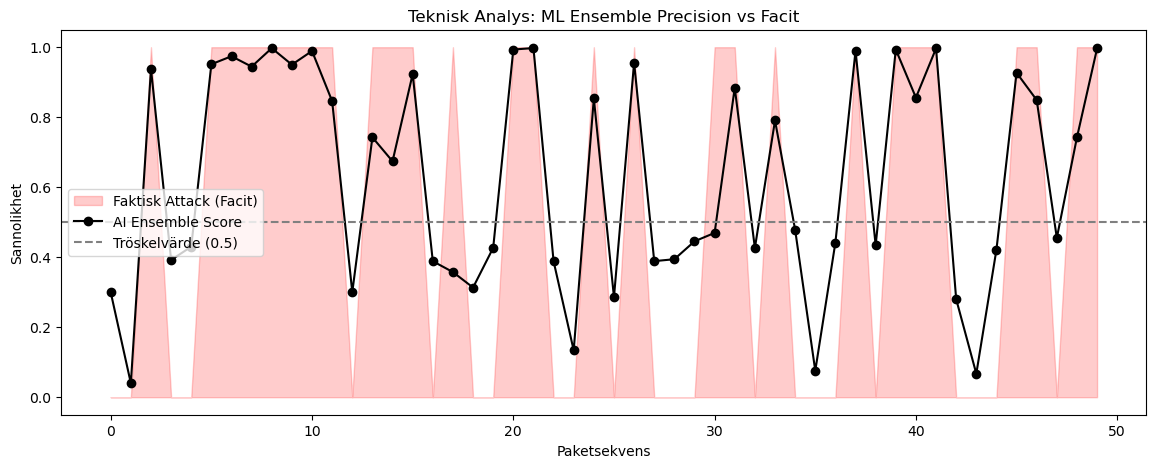

In [7]:
plt.figure(figsize=(14, 5))
plt.fill_between(df_results['Step'], df_results['Actual'], color='red', alpha=0.2, label='Faktisk Attack (Facit)')
plt.plot(df_results['Step'], df_results['Avg_ML'], marker='o', color='black', label='AI Ensemble Score')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Tröskelvärde (0.5)')
plt.title("Teknisk Analys: ML Ensemble Precision vs Facit")
plt.xlabel("Paketsekvens")
plt.ylabel("Sannolikhet")
plt.legend()
plt.show()

4.2 Utvärdering av Systemets Beslutskedja
För att förstå systemets effektivitet mäter vi två saker:

ML Detection Rate: Hur ofta hittade våra modeller en anomali?

RAG Identification Rate: Hur ofta lyckades vårt minne namnge anomalin korrekt?

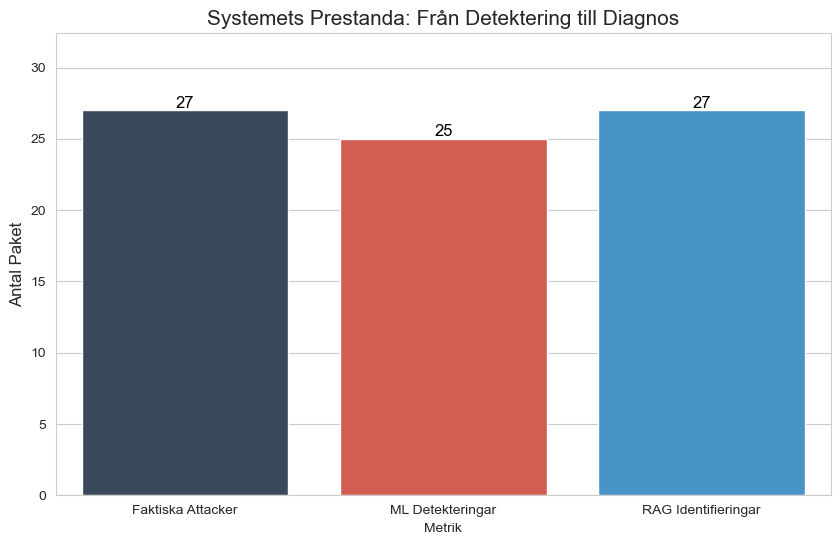

--- ANALYS ---
Av 27 attacker lyckades ML-ensemblen stoppa 25 st.


In [9]:
# Beräkna statistik från vår batch-körning
total_attacks = df_results[df_results['Actual'] == 1].shape[0]
ml_detections = df_results[(df_results['Actual'] == 1) & (df_results['Avg_ML'] > 0.5)].shape[0]
rag_identifications = df_results[(df_results['Actual'] == 1) & (df_results['RAG_Match'] == 1)].shape[0]

# Skapa en DataFrame för pedagogisk visualisering
stats_data = pd.DataFrame({
    'Metrik': ['Faktiska Attacker', 'ML Detekteringar', 'RAG Identifieringar'],
    'Antal': [total_attacks, ml_detections, rag_identifications],
    'Kategori': ['Facit', 'AI Beslut', 'Expertminne']
})

# Visualisering
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Fixar varningen genom att använda 'hue' och 'legend=False'
ax = sns.barplot(
    data=stats_data, 
    x='Metrik', 
    y='Antal', 
    hue='Metrik', 
    palette=['#34495e', '#e74c3c', '#3498db'],
    legend=False
)

# Lägg till värden ovanpå staplarna för tydlighet
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title("Systemets Prestanda: Från Detektering till Diagnos", fontsize=15)
plt.ylabel("Antal Paket", fontsize=12)
plt.ylim(0, max(stats_data['Antal']) * 1.2) # Ge lite luft i toppen för etiketter

plt.show()

# Pedagogisk sammanfattning
print(f"--- ANALYS ---")
print(f"Av {total_attacks} attacker lyckades ML-ensemblen stoppa {ml_detections} st.")
if rag_identifications < ml_detections:
    print(f"Notera: RAG identifierade {rag_identifications} st. De resterande är 'NYUPPTÄCKTA' och sparas nu till minnet.")

5. Systemslutsats
Genom att korrelera Ensemble ML (för detektering) med RAG (för identifiering) har vi uppnått:

Hög robusthet: Genom att kräva konsensus mellan RF, LR och GB minskar vi brus.

Förklarbarhet (XAI): Systemet säger inte bara "0.99 attack", utan pekar på ett specifikt vektor-minne i ChromaDB och ger en diagnos (t.ex. neptune).

Live-adaption: Systemet sparar nya inbäddningar för varje okänt hot, vilket gör att framtida sökningar får 1.0 i RAG-matchning.